In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_taxi_data.csv")

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

/var/folders/0d/8z298r691kbfwbztnkk4zq840000gn/T/ipykernel_9418/4095837661.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_taxi_data.csv")


In [3]:
hourly_df = df.set_index("tpep_pickup_datetime").resample("H").agg({
    "trip_distance":"count",
    "total_amount":"mean"
})

hourly_df.rename(columns={
    "trip_distance":"trips",
    "total_amount":"avg_fare"
}, inplace=True)

hourly_df = hourly_df.dropna()

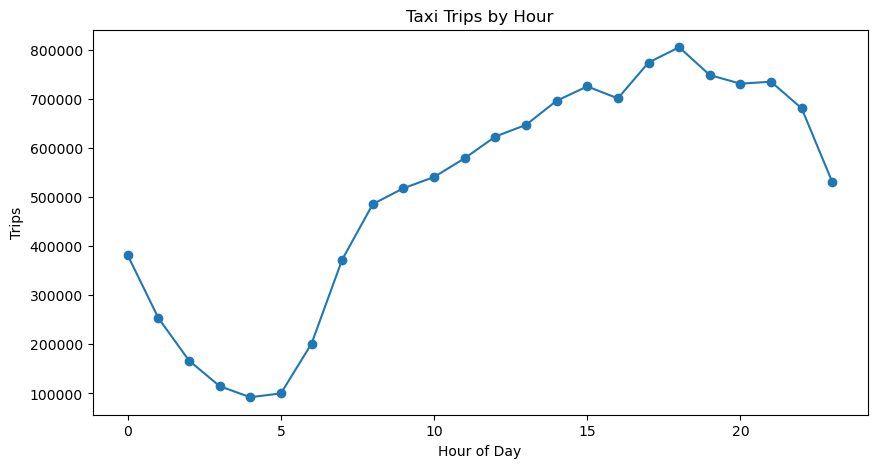

In [6]:
hourly_trips = df.groupby("pickup_hour").size()

plt.figure(figsize=(10,5))
hourly_trips.plot(marker="o")
plt.title("Taxi Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Trips")

plt.savefig("hourly_demand.png")
plt.show()

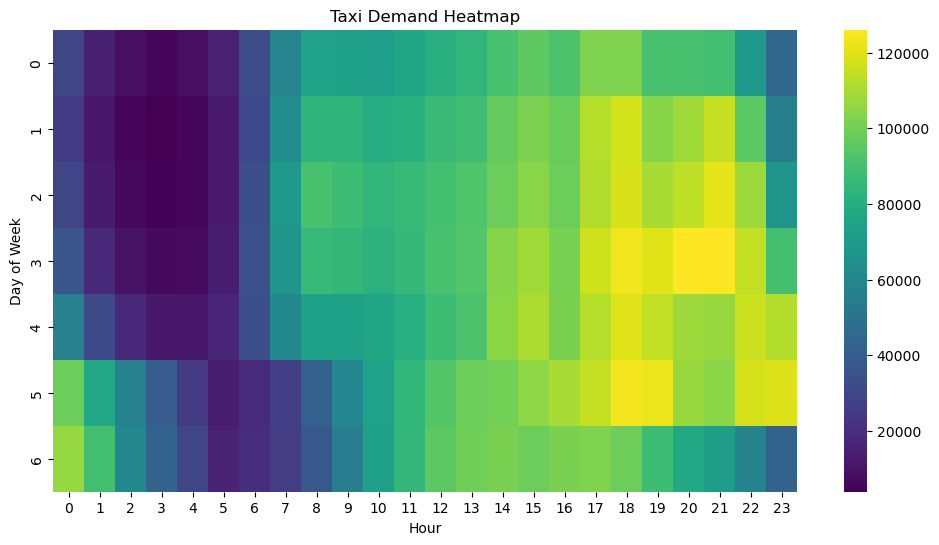

In [7]:
heatmap_data = df.groupby(["pickup_day","pickup_hour"]).size().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="viridis")

plt.title("Taxi Demand Heatmap")
plt.xlabel("Hour")
plt.ylabel("Day of Week")

plt.savefig("demand_heatmap.png")
plt.show()

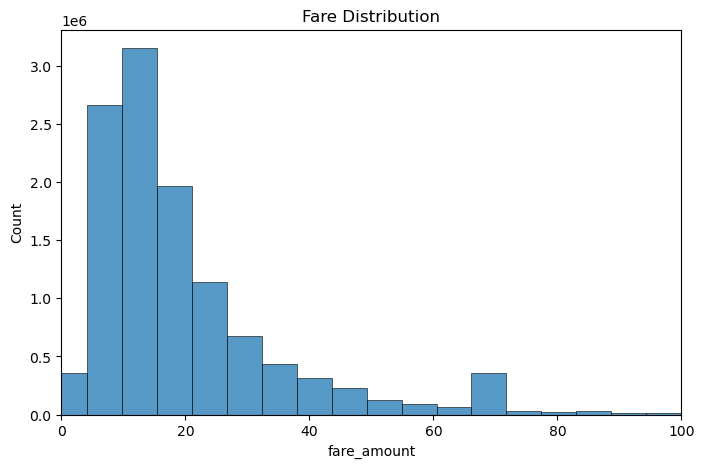

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["fare_amount"], bins=100)

plt.xlim(0,100)
plt.title("Fare Distribution")

plt.savefig("fare_distribution.png")
plt.show()

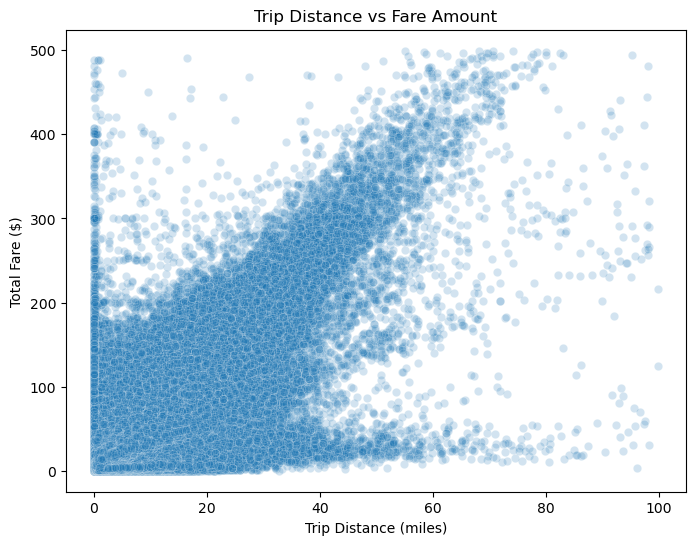

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["trip_distance"],
    y=df["total_amount"],
    alpha=0.2
)

plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Total Fare ($)")

plt.savefig("distance_vs_fare.png")
plt.show()